<a href="https://colab.research.google.com/github/ssykes-eth/ETH_273-0003-00L/blob/weekend_4/adv-attack/adversarial_attacks_cx.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

FGSM Attack — SOLUTION

**Goal:** Implement the Fast Gradient Sign Method (FGSM) and evaluate its effectiveness at different perturbation strengths.

## FGSM attack

In the following, we ask you to implement the FGSM attack.
The Fast Gradient Sign Method (FGSM) is an adversarial attack algorithm used to generate adversarial examples for neural networks. It was introduced by [Goodfellow et al. in 2014.](https://arxiv.org/abs/1412.6572) The goal of FGSM is to perturb an input to a model in such a way that the model makes a mistake, while the perturbation is small enough to be imperceptible to humans.

Here is the FGSM algorithm:

1. **Input:**
   - A trained model $N$.
   - An input example $x$ and its true label $y$.
   - A loss function $L(y, N(x))$ that compares the true label $y$ with the prediction $N(x)$ .
   - A small perturbation parameter $\epsilon$.

2. **Output:**
   - An adversarial example $x_{adv}$.

3. **Algorithm:**
   - Compute the gradient of the loss with respect to the input $x$: $\nabla_x L(y, N(x))$.
   - Create the adversarial example by adding a small perturbation in the direction of the gradient's sign:
     $$
     x_{adv} = \text{clip}(x + \epsilon \cdot \text{sign}(\nabla_x L(y, N(x)))).
     $$
   - Here, the function $\text{clip}$ clips the resulting example $x'$ to ensure it is within the valid range for input values (e.g., pixel values between 0 and 255 for images).

The perturbation $\epsilon \cdot \text{sign}(\nabla_x L(y, N(x)))$ is designed to increase the loss, thereby making the model more likely to misclassify the input. The sign function ensures that the perturbation is small and uniform in each dimension.

This simple yet effective method highlights the vulnerability of neural networks to adversarial examples and has inspired further research into more sophisticated attack and defense mechanisms.

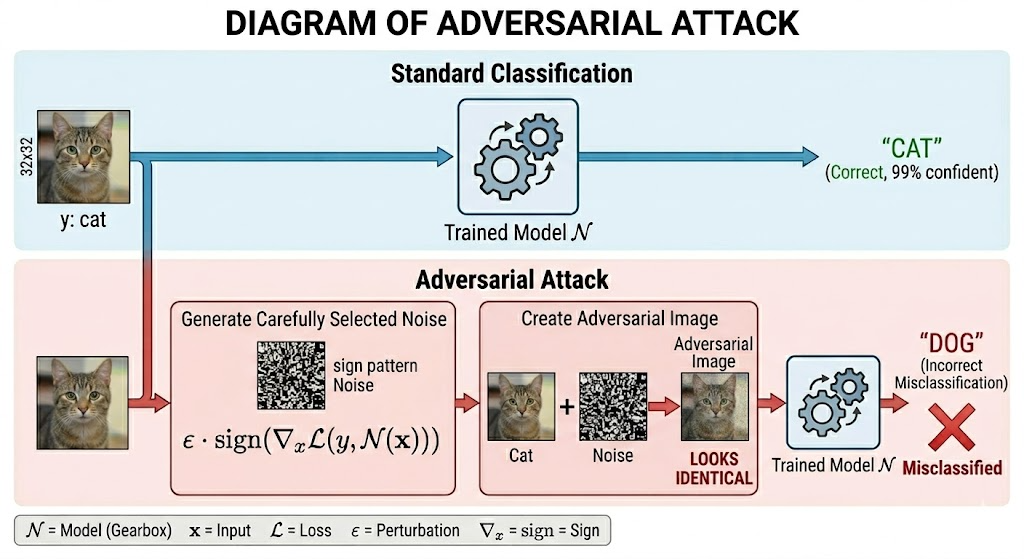

---

This version of the algorithm is **untargeted**. This means that we don't aim at changing the label to some specific target, but "just" at misclassifying our prediction.

## 2. Attacking the Input, Not the Model

One of the most important concepts to grasp about the **Fast Gradient Sign Method (FGSM)** is where the "attack" actually happens.

In many security contexts, an "attack" implies modifying a system's source code or corrupting its internal logic. In adversarial machine learning, the **model remains untouched**. We are not retraining the network, changing its weights, or modifying its architecture. We don't even need internal access to the model's development pipeline.

**We need, however, access to the internal gradients of the model**. This means that our attack is **white-box**, and cannot work with black-box models/

### The Dataset: CIFAR-10
To test our attack, we are using the **CIFAR-10** dataset, a classic benchmark in computer vision. It is made of 60,000 color images categorized into 10 mutually exclusive classes (airplane, automobile, bird, cat, deer, dog, frog, horse, ship, and truck). Each image is tiny, only **32x32 pixels**.

### Loading the Pre-trained Target
To prove that we don't need to control the model-building process, we will use a pre-trained **ResNet20** model. This model was independently trained and hosted via `torch.hub`.

In the following cell, we load the model and define a helper function to see what the gearbox predicts for our images.

In [ ]:
# @title Setup: Load Model and Data { display-mode: "form" }

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

print("⏳ Loading pre-trained ResNet20 and CIFAR-10 data...")

# Load pretrained ResNet20 trained on CIFAR-10, set to eval mode
model = torch.hub.load('chenyaofo/pytorch-cifar-models', 'cifar10_resnet20', pretrained=True, verbose=False)
model.eval()

# Load 100 CIFAR-10 test images
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2470, 0.2435, 0.2616])
])

testset = torchvision.datasets.CIFAR10(root='../data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=100, shuffle=False)
images, labels = next(iter(testloader))

CIFAR10_CLASSES = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

def predict(model, x):
    """Returns the predicted class indices for a batch of images."""
    with torch.no_grad():
        logits = model(x)
    return logits.argmax(dim=1)

# Evaluate clean accuracy to verify setup
clean_preds = predict(model, images)
accuracy = (clean_preds == labels).float().mean()

print(f"\n✅ Loading complete!")
print(f"Base Model Accuracy: {accuracy:.2%}")

## 3. 🎯🎯🎯 YOUR TASK 🎯🎯🎯: Implementing the FGSM Attack

Now it is your turn to implement the **Fast Gradient Sign Method**. Refer back to the diagram and the formal definition:

$$x_{adv} = \text{clip}(x + \epsilon \cdot \text{sign}(\nabla_x L(y, N(x))))$$

Your goal is to complete the `fgsm_attack` function. Unlike standard training where we calculate gradients to update model weights, here we need the gradient with respect to the **input pixels**.

### Implementation Hints

1.  **Enable Gradient Tracking:** PyTorch doesn't track gradients for input data by default. You need to explicitly tell the tensor to start "watching" its own gradients. Look into `.requires_grad_()`.
2.  **The Forward Pass:** Pass your input through the model and calculate the loss. Since we want to fool the model, we use the standard `CrossEntropyLoss` to see how "far" the current prediction is from the true label.
3.  **The Backward Pass:** Usually, `loss.backward()` calculates gradients for the model's weights. Because you enabled gradient tracking on the input tensor in Step 1, this will now also populate the `.grad` attribute of your image.
4.  **The Perturbation:** This is the core of FGSM. You need to move the pixels in the direction that **increases** the loss. Use the `sign()` of the gradient and scale it by your perturbation parameter $\epsilon$.
5.  **Staying Within Bounds:** After adding noise, some pixel values might exceed the valid range (0 to 1, or the min/max of your normalized data). Use a "clamping" or "clipping" function to ensure the adversarial image remains a valid image.

In [ ]:
# SOLUTION
def fgsm_attack(model, images, labels, epsilon):
    """
    FGSM: x_adv = x + epsilon * sign(grad_x Loss(model(x), labels))
    """
    # 🎯🎯🎯 TODO 🎯🎯🎯 1.  Create leaf tensor with gradient tracking
    x = ...
    # 🎯🎯🎯 TODO 🎯🎯🎯 2. Forward pass + loss
    loss = ...
    # 🎯🎯🎯 TODO 🎯🎯🎯 3. Backward to get gradient w.r.t. input
    ...
    # 🎯🎯🎯 TODO 🎯🎯🎯 4. Apply signed gradient perturbation (don't clip yet)
    x_adv = ...
    # 🎯🎯🎯 TODO 🎯🎯🎯 5. Clamp to the approximate valid range for ImageNet-normalized images
    x_adv = ...
    return x_adv.detach()

In [ ]:
# @title Let's look at the result of our attack! { display-mode: "form" }

# @markdown On the first row, you'll see the original image. On the second row,
# @markdown the noise that your FGSM attack generates. On the last row, the new
# @markdown image, together with the updated prediction of your model.

# @markdown Will you manage to fool the model?

# Even smaller figsize to keep pixels dense
def denormalize(tensor, mean=[0.4914, 0.4822, 0.4465], std=[0.2470, 0.2435, 0.2616]):
    """Reverse CIFAR-10 normalization for display."""
    t = tensor.clone()
    for i in range(3):
        t[i] = t[i] * std[i] + mean[i]
    return torch.clamp(t, 0, 1)

eps_viz = 0.1
adv_images_viz = fgsm_attack(model, images, labels, eps_viz)
adv_preds_viz = predict(model, adv_images_viz)

fig, axes = plt.subplots(3, 5, figsize=(8, 5))

row_titles = ['Original', 'Noise (scaled)', 'Adversarial']
for row in range(3):
    axes[row, 0].set_ylabel(row_titles[row], fontsize=9, fontweight='bold')

for i in range(5):
    # Data Processing
    orig = denormalize(images[i]).permute(1, 2, 0).numpy()
    adv  = denormalize(adv_images_viz[i]).permute(1, 2, 0).numpy()
    pert = adv_images_viz[i] - images[i]
    # Normalize noise to [0, 1] for visualization
    pert_v = ((pert - pert.min()) / (pert.max() - pert.min() + 1e-8)).permute(1, 2, 0).numpy()

    # --- Row 1: Original ---
    axes[0, i].imshow(orig, interpolation='nearest')
    axes[0, i].set_title(f'T: {CIFAR10_CLASSES[labels[i].item()]}', fontsize=8)
    axes[0, i].axis('off')

    # --- Row 2: Perturbation (The missing text!) ---
    axes[1, i].imshow(pert_v, interpolation='nearest')
    axes[1, i].set_title('Noise', fontsize=7, color='gray') # Subtle label for the noise
    axes[1, i].axis('off')

    # --- Row 3: Adversarial ---
    axes[2, i].imshow(adv, interpolation='nearest')
    pred_label = CIFAR10_CLASSES[adv_preds_viz[i].item()]
    true_label = CIFAR10_CLASSES[labels[i].item()]
    color = 'tab:red' if pred_label != true_label else 'tab:green'
    axes[2, i].set_title(f'P: {pred_label}', fontsize=8, color=color, fontweight='bold')
    axes[2, i].axis('off')

# Increase spacing significantly
# wspace = width padding between columns
# hspace = height padding between rows
plt.subplots_adjust(wspace=0.6, hspace=0.8)

plt.suptitle(f'FGSM Attack (ε={eps_viz})', fontsize=11, y=0.98, fontweight='bold')
plt.show()

## 4. The Role of Epsilon ($\epsilon$)

The parameter **$\epsilon$** (epsilon) represents the "perturbation budget." It is the maximum amount any single pixel is allowed to change.

There is a fundamental trade-off in adversarial machine learning: a higher $\epsilon$ makes the attack more powerful, causing the model's accuracy to plummet. However, it also makes the noise more obvious to the human eye.

Ideally, we want the smallest possible $\epsilon$ that still causes a misclassification. This ensures the image **looks identical** to a human but is **categorized incorrectly** by the machine.

Below, we evaluate the model across a range of epsilon values to find the "breaking point" of the ResNet20 gearbox.

In [ ]:
# @title Epsilon Evaluation & Dual-Image Visualizer { display-mode: "form" }
import matplotlib.pyplot as plt

# 1. Run global evaluation (now up to 1.0)
epsilons = [0, 0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0]
adv_accuracies = []

for eps in epsilons:
    adv_images = fgsm_attack(model, images, labels, eps)
    adv_preds = predict(model, adv_images)
    acc = (adv_preds == labels).float().mean().item()
    adv_accuracies.append(acc)

# @markdown ---
# @markdown ### 2. Interactive Visualizer
# @markdown Watch how the image degrades as epsilon approaches 1.0.
selected_epsilon = 0.1 # @param {type:"slider", min:0, max:1.0, step:0.01}
image_idx = 19 # @param {type:"slider", min:1, max:99, step:1}

# Generate specific example
target_img = images[image_idx:image_idx+1]
target_lbl = labels[image_idx:image_idx+1]
adv_example = fgsm_attack(model, target_img, target_lbl, selected_epsilon)
pred = predict(model, adv_example).item()

# Helper for display
def show_img(img_tensor):
    img = img_tensor.squeeze().clone().detach()
    for i, (m, s) in enumerate(zip([0.4914, 0.4822, 0.4465], [0.2470, 0.2435, 0.2616])):
        img[i] = img[i] * s + m
    return img.clamp(0, 1).permute(1, 2, 0).numpy()

# Plotting Layout
fig = plt.figure(figsize=(12, 8))
gs = fig.add_gridspec(2, 2)

# Subplot 1: Accuracy Curve (Occupies the left column)
ax_acc = fig.add_subplot(gs[:, 0])
ax_acc.plot(epsilons, adv_accuracies, 'o-', color='tab:red', linewidth=2, label='Adv Accuracy')
ax_acc.axvline(x=selected_epsilon, color='gray', linestyle='--', label=f'Current ε ({selected_epsilon})')
ax_acc.set_xlabel('Epsilon (Perturbation Strength)')
ax_acc.set_ylabel('Model Accuracy')
ax_acc.set_title('The Accuracy Drop-off')
ax_acc.grid(True, alpha=0.3)
ax_acc.set_ylim(-0.05, 1.05)
ax_acc.legend()

# Subplot 2: Original Image (Top Right)
ax_orig = fig.add_subplot(gs[0, 1])
ax_orig.imshow(show_img(target_img), interpolation='nearest')
ax_orig.set_title(f"Original: {CIFAR10_CLASSES[target_lbl.item()]}", fontweight='bold')
ax_orig.axis('off')

# Subplot 3: Adversarial Image (Bottom Right)
ax_adv = fig.add_subplot(gs[1, 1])
ax_adv.imshow(show_img(adv_example), interpolation='nearest')
true_name = CIFAR10_CLASSES[target_lbl.item()]
pred_name = CIFAR10_CLASSES[pred]
color = 'tab:red' if true_name != pred_name else 'tab:green'
ax_adv.set_title(f"Adversarial Pred: {pred_name}", color=color, fontweight='bold')
ax_adv.axis('off')

plt.tight_layout()
plt.show()

print(f"Current Accuracy at ε={selected_epsilon}: ~{adv_accuracies[min(range(len(epsilons)), key=lambda i: abs(epsilons[i]-selected_epsilon))]:.2%}")

# And now... how do we defend?

We have seen how, using a simple attack like FGSM, we are able to fool a model into misclassifying its inputs.

Next, we ask you to implement adversarial training to defend the model against these types of adversarial attacks. We don't want *our* models to be vulnerable, after all!

To refresh your memory, adversarial training works as follows:

1. Sample a batch of images and their labels.
2. Perturb the images using an adversarial attack. Use the `fgsm_attack` that you have created above for this!
3. Obtain predictions for the perturbed images.
4. Obtain predictions for the unperturbed images.
5. Compute the loss for both the perturbed and unperturbed images, and average them.
6. Compute the gradient of the averaged loss and optimize it using an optimizer.

Complete the `train_adversarial` function logic below. This function should implement the adversarial training steps described here.Here are a few important points to take away:

* **Mode Switching:** You must manage the model's state using `model.train()` and `model.eval()`. When generating adversarial examples with your `fgsm_attack`, the model should be in **evaluation mode** to ensure deterministic behavior. Switch back to **training mode** before calculating the loss for the weight update.
* **Gradient Management:** Unlike some other frameworks, PyTorch accumulates gradients. You must call `optimizer.zero_grad()` at the start of each batch to clear out the gradients from the previous iteration.
* **Device Consistency:** Since we are using hardware acceleration, ensure you move your `images` and `labels` to the `device` (GPU/CPU) using `.to(device)` before passing them to the model.
* **The Update Cycle:** To update the model parameters, you first call `total_loss.backward()` to compute the gradients and then `optimizer.step()` to apply the optimization step (e.g., Adam).
* **Combined Loss:** Remember that we have to compute two separate losses: one for the clean images and one for the adversarial ones. Then we average them. This ensures the model maintains high accuracy on normal data while learning to resist attacks.


In [ ]:
# @title Setup: Environment and Evaluation Batch { display-mode: "form" }

# 1. Define the device (Hardware Acceleration)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device) # Move your existing model to the device

print(f"🚀 Using device: {device}")

# 2. Setup Training Data (The missing pieces)
# We need the full training set for the adversarial training exercise
trainset = torchvision.datasets.CIFAR10(root='../data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True)

# 3. Create the fixed evaluation batch (512 images)
# We pull this from the test set to monitor how the model improves
eval_loader = torch.utils.data.DataLoader(testset, batch_size=512, shuffle=False)
images_eval, labels_eval = next(iter(eval_loader))

# Move the eval batch to the device immediately
images_eval = images_eval.to(device)
labels_eval = labels_eval.to(device)

print(f"✅ Training set loaded ({len(trainset):,} images)")
print(f"✅ Evaluation batch created ({len(images_eval)} images on {device})")

# 2. Define the evaluation helper for adversarial training
def print_epoch_stats(epoch, epochs, model, images_eval, labels_eval, epsilon):
    """Prints accuracy on clean vs adversarial images to track progress."""
    model.eval()

    # Clean accuracy on the eval batch
    clean_preds = predict(model, images_eval)
    clean_acc = (clean_preds == labels_eval).float().mean().item()

    # Adversarial accuracy on the eval batch
    # Note: we use the fgsm_attack the students implemented!
    adv_images = fgsm_attack(model, images_eval, labels_eval, epsilon)
    adv_preds = predict(model, adv_images)
    adv_acc = (adv_preds == labels_eval).float().mean().item()

    print(f"📊 [Epoch {epoch}/{epochs}] "
          f"Clean Acc: {clean_acc:>6.2%} | "
          f"Adv Acc (ε={epsilon}): {adv_acc:>6.2%}")

    model.train()

print("✅ Training loader ready.")
print("✅ Helper 'print_epoch_stats' defined.")

In [ ]:
# @title 🎯🎯🎯 YOUR TASK 🎯🎯🎯: Implementing the Adversarial training loop
import copy

# 1. Clone the model to keep the original for comparison
# We use .to(device) to ensure the new model is on the GPU/CPU
robust_model = copy.deepcopy(model).to(device)
print("🛡️ Created a clone of the model for adversarial training...")

# 2. Implementation of the training loop
def train_adversarial(model, train_loader, images_eval, labels_eval, epsilon=0.1, epochs=3):
    optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)
    criterion = torch.nn.CrossEntropyLoss()

    print(f"Running for {epochs} epochs. This might take a moment...")
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for images, labels in train_loader:
            # Move batch to the same device as the model
            images, labels = images.to(device), labels.to(device)

            # 🎯🎯🎯 TODO 🎯🎯🎯 - Generate adversarial images (pay attention to the model mode)
            # The images and their labels are in the `images` and `labels` tensors respectively
            ...
            adv_images = ...

            # 🎯🎯🎯 TODO 🎯🎯🎯 - Update the model (pay attention to the mode)
            ...


            # 🎯🎯🎯 TODO 🎯🎯🎯 - Compute the losses
            loss_clean = ...
            loss_adv   = ...
            total_loss = ...

            total_loss.backward()
            optimizer.step()
            running_loss += total_loss.item()

        # --- STEP C: STATS ---
        # This uses the images_eval and labels_eval we just defined
        print_epoch_stats(epoch + 1, epochs, model, images_eval, labels_eval, epsilon)

# 3. Execution
train_adversarial(robust_model, train_loader, images_eval, labels_eval, epsilon=0.1, epochs=10)

In [ ]:
# @title Robustness Benchmark: Original vs. Robust { display-mode: "form" }

# @markdown Let's compared the accuracy of the original model and the one of the
# @markdown model we have trained in an adversarial way. Which one is more robust?

# Benchmark range
test_epsilons = [0, 0.01, 0.05, 0.1, 0.2, 0.3, 0.5, 0.8]
orig_accs = []
robust_accs = []

print("📊 Benchmarking models... (this may take a moment)")

for eps in test_epsilons:
    # Original Model
    adv_orig = fgsm_attack(model, images_eval, labels_eval, eps)
    acc_orig = (predict(model, adv_orig) == labels_eval).float().mean().item()
    orig_accs.append(acc_orig)

    # Robust Model
    adv_robust = fgsm_attack(robust_model, images_eval, labels_eval, eps)
    acc_robust = (predict(robust_model, adv_robust) == labels_eval).float().mean().item()
    robust_accs.append(acc_robust)

# Visualization
plt.figure(figsize=(10, 6))
plt.plot(test_epsilons, orig_accs, 'o--', color='tab:gray', label='Original Model (Brittle)', alpha=0.6)
plt.plot(test_epsilons, robust_accs, 'o-', color='tab:blue', linewidth=3, label='Robust Model (Adversarially Trained)')

plt.fill_between(test_epsilons, orig_accs, robust_accs, color='tab:blue', alpha=0.1, label='Robustness Gain')

plt.xlabel('Attack Strength (Epsilon)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('The Robustness Gap: How Adversarial Training Protects the Model', fontsize=14, fontweight='bold')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.ylim(0, 1.05)
plt.show()